# cir2c — RQ2 / RQ3 analysis

Parsing of the BenchExec result files under `../results/results/normalized/`.

## The three suites (configs)

| config | what it is | #tasks |
|--------|------------|-------:|
| `esbmc-eval` | original ESBMC-eval benchmarks (C++) | 374 |
| `esbmc-eval-mapped` | cir2c output, `--externalize-std` (std kept as nondet externs) | 1011 |
| `esbmc-eval-mapped-nostd` | cir2c output, `--no-externalize-std` (std inlined) | 178 |

`esbmc-eval-mapped-nostd` is a strict subset of `esbmc-eval-mapped` (the 178 tasks
where inlining std also succeeded). The original C++ suite shares 288 task names
with the mapped suite (the rest differ by `-c++NN` naming suffixes / mapping drops).

## Tools per config

- **All 29 verifiers** run the two mapped suites (`esbmc-eval-mapped`, `esbmc-eval-mapped-nostd`).
- **Only the 3 natively-C++-capable verifiers** — `esbmc-kind`, `cbmc`, `divine` —
  additionally run the original `esbmc-eval` (C++) suite.
- Baseline for the `esbmc-vs-<tool>` comparison is **`esbmc-kind`**.

Tools: 2ls, bubaak, bubaak-split, cbmc, cpachecker, cpv, crux, divine, emergentheta,
esbmc-kind, goblint, goblint-par, goblitch, graves, infer, mopsa, nacpa, pinaka,
re3ver, svf-svc, symbiotic, theta, thorn, uautomizer, ukojak, uparalizer, utaipan,
veriabs, veriabsl.


In [1]:
import bz2
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path("../results/results/normalized")

# Verifiers that natively handle C++ and so also ran the original (un-mapped) suite.
# This is the one fixed fact. Suite/config names are *discovered* from the result
# files (next cell), so renamed suites or additional mapped suites need no edits here.
NATIVE_CPP_TOOLS = ["esbmc-kind", "cbmc", "divine"]
BASELINE = "esbmc-kind"

# <tool>.<YYYY-MM-DD_HH-MM-SS>.results.<config>.<config>.xml.bz2
FNAME_RE = re.compile(
    r"^(?P<tool>.+?)\.(?P<date>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.results\.(?P<config>[^.]+)\."
)


In [2]:
def _seconds(v):
    """'0.123s' -> 0.123 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("s")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _bytes(v):
    """'5607424B' -> 5607424.0 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("B")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _verdict(status):
    """Collapse a raw BenchExec status to true / false / unknown."""
    s = (status or "").lower()
    if s.startswith("true"):
        return "true"
    if s.startswith("false"):
        return "false"
    return "unknown"  # timeout, out of memory, any ERROR/EXCEPTION, plain 'unknown'


def parse_file(path: Path) -> list[dict]:
    m = FNAME_RE.match(path.name)
    tool, config = m["tool"], m["config"]
    root = ET.fromstring(bz2.open(path).read())
    out = []
    for run in root.findall("run"):
        cols = {c.get("title"): c.get("value") for c in run.findall("column")}
        name = run.get("name")
        out.append(
            {
                "tool": tool,
                "config": config,
                "task": name,                       # joins across suites (normalized)
                "group": name.split("/", 1)[0],     # algorithm / cbmc / ... (SV-COMP-style group)
                "expected": run.get("expectedVerdict"),   # ground-truth label: true / false
                "status": cols.get("status"),             # raw verifier status
                "bx_category": cols.get("category"),       # BenchExec: correct/wrong/unknown/error
                "verdict": _verdict(cols.get("status")),   # true / false / unknown
                "cputime": _seconds(cols.get("cputime")),  # seconds
                "walltime": _seconds(cols.get("walltime")),  # seconds
                "memory": _bytes(cols.get("memory")),      # bytes
                "termination": cols.get("terminationreason"),
            }
        )
    return out


df = pd.DataFrame(
    [row for f in sorted(RESULTS_DIR.glob("*.xml.bz2")) for row in parse_file(f)]
)

# --- Discover suites from the data (robust to renames and to extra mapped suites) ---
# A "mapped" suite is any C suite run by more verifiers than just the native-C++ trio;
# the original C++ suite(s) are run only by those. No suite name is hardcoded.
tools_per_config = df.groupby("config").tool.nunique()
MAPPED_CONFIGS = sorted(tools_per_config.index[tools_per_config > len(NATIVE_CPP_TOOLS)])
ORIGINAL_CONFIGS = sorted(c for c in tools_per_config.index if c not in MAPPED_CONFIGS)
CONFIGS = ORIGINAL_CONFIGS + MAPPED_CONFIGS  # display order: originals first

df["config"] = pd.Categorical(df["config"], CONFIGS, ordered=True)
# Correctness of the verdict vs. the suite label: True / False / NaN(=inconclusive).
df["correct"] = df["bx_category"].map({"correct": True, "wrong": False})

print(f"{len(df):,} rows | {df.tool.nunique()} tools")
print(f"  mapped suites:   {MAPPED_CONFIGS}")
print(f"  original suites: {ORIGINAL_CONFIGS}")
df.head()


35,603 rows | 29 tools
  mapped suites:   ['esbmc-eval-mapped', 'esbmc-eval-mapped-nostd']
  original suites: ['esbmc-eval']


,tool,config,task,group,expected,status,bx_category,verdict,cputime,walltime,memory,termination,correct
0,2ls,esbmc-eval-mapped-nostd,algorithm/algorithm51/algorithm_algorithm51.yml,algorithm,true,unknown,unknown,unknown,0.123346,3.738780,4939776.0,None,NaN
1,2ls,esbmc-eval-mapped-nostd,cbmc/Templates1/cbmc_Templates1.yml,cbmc,true,unknown,unknown,unknown,0.119259,3.769874,4952064.0,None,NaN
2,2ls,esbmc-eval-mapped-nostd,cbmc/Templates10/cbmc_Templates10.yml,cbmc,true,unknown,unknown,unknown,0.113157,3.746500,4788224.0,None,NaN
3,2ls,esbmc-eval-mapped-nostd,cbmc/Templates11/cbmc_Templates11.yml,cbmc,true,unknown,unknown,unknown,0.128065,1.599969,4976640.0,None,NaN
4,2ls,esbmc-eval-mapped-nostd,cbmc/Templates12/cbmc_Templates12.yml,cbmc,true,unknown,unknown,unknown,0.113083,1.614018,5070848.0,None,NaN


In [3]:
# Drop C verifiers that never produced a single true/false verdict (only unknown) —
# they contribute nothing to verdict agreement. Done right after parsing so every
# downstream cell sees only the conclusive verifiers.
conclusive_tools = df.loc[df.verdict.isin(["true", "false"]), "tool"].unique()
dropped_tools = sorted(set(df.tool) - set(conclusive_tools))
df = df[df.tool.isin(conclusive_tools)].copy()

print(f"Dropped {len(dropped_tools)} unknown-only verifiers: {dropped_tools}")
print(f"Remaining: {df.tool.nunique()} verifiers")


Dropped 10 unknown-only verifiers: ['cpv', 'crux', 'goblint', 'goblint-par', 'goblitch', 'graves', 'infer', 're3ver', 'symbiotic', 'veriabsl']
Remaining: 19 verifiers


In [4]:
# Which tool ran which suite, and on how many tasks (blank = not run).
runs = df.pivot_table(
    index="tool", columns="config", values="task", aggfunc="count", observed=False
)
display(runs)

# Per-suite outcome breakdown (verdict vs. suite label).
summary = (
    df.groupby("config", observed=True)
    .agg(
        runs=("task", "count"),
        correct=("correct", lambda s: int((s == True).sum())),
        wrong=("correct", lambda s: int((s == False).sum())),
        inconclusive=("verdict", lambda s: int((s == "unknown").sum())),
        said_true=("verdict", lambda s: int((s == "true").sum())),
        said_false=("verdict", lambda s: int((s == "false").sum())),
    )
)
display(summary)


config,esbmc-eval,esbmc-eval-mapped,esbmc-eval-mapped-nostd
tool,,,
2ls,0,1011,178
bubaak,0,1011,178
bubaak-split,0,1011,178
cbmc,374,1011,178
cpachecker,0,1011,178
divine,374,1011,178
emergentheta,0,1011,178
esbmc-kind,374,1011,178
mopsa,0,1011,178


,runs,correct,wrong,inconclusive,said_true,said_false
config,,,,,,
esbmc-eval,1122,471,40,611,383,128
esbmc-eval-mapped,19209,4450,2909,11850,1821,5538
esbmc-eval-mapped-nostd,3382,1805,178,1399,1360,623


## Sanity check: answers returned on the mapped (C) suites

Every distinct BenchExec `category` and raw verifier `status` produced by the C
verifiers, and how each status collapses into our `true` / `false` / `unknown`.


In [5]:
# Restrict to the mapped (C) suites — these are what the C verifiers actually consume.
mapped = df[df.config.isin(MAPPED_CONFIGS)]

print("BenchExec categories:", sorted(mapped.bx_category.dropna().unique()))
print(f"Distinct raw statuses: {mapped.status.nunique()}\n")

status_tbl = (
    mapped.groupby("status")
    .agg(verdict=("verdict", "first"), n=("task", "size"))
    .sort_values("n", ascending=False)
)
status_tbl


BenchExec categories: ['correct', 'error', 'unknown', 'wrong']
Distinct raw statuses: 21



,verdict,n
status,,
false(unreach-call),false,6161
unknown,unknown,4463
true,true,3181
"ERROR (frontend failed, before parsing finished)",unknown,1398
TIMEOUT,unknown,1241
ERROR (6),unknown,1187
ERROR (134),unknown,1187
ERROR (1),unknown,882
"ERROR (server error, after parsing finished)",unknown,701


In [6]:
import matplotlib.pyplot as plt

# Export targets: figures/<rq>/ holds <name>.pdf (plots) and <name>.tex (a figure or
# table environment that \input-s into the paper; paths are relative to this folder,
# where evaluation.tex also lives).
FIG_ROOT = Path("figures")
for _rq in ("rq2", "rq3"):
    (FIG_ROOT / _rq).mkdir(parents=True, exist_ok=True)


def export_fig(fig, rq, name, caption, label=None, width=r"\linewidth"):
    """Save fig as figures/<rq>/<name>.pdf + a sibling .tex figure environment, show it."""
    label = label or "fig:" + name.replace("_", "-")
    fig.savefig(FIG_ROOT / rq / f"{name}.pdf", bbox_inches="tight")
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{figure}[t]\n  \\centering\n"
        f"  \\includegraphics[width={width}]{{figures/{rq}/{name}.pdf}}\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        "\\end{figure}\n",
        encoding="utf-8",
    )
    display(fig)
    plt.close(fig)


def export_table(frame, rq, name, caption, label=None, **to_latex_kw):
    """Write a LaTeX table environment wrapping frame.to_latex to figures/<rq>/<name>.tex."""
    label = label or "tab:" + name.replace("_", "-")
    opts = dict(index=True, escape=True, float_format="%.4g")
    opts.update(to_latex_kw)
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{table}[t]\n  \\centering\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        f"{frame.to_latex(**opts)}"
        "\\end{table}\n",
        encoding="utf-8",
    )
    return frame  # so callers can `display(export_table(...))`


## Verifier agreement per task

For each task we collapse the answers of the retained C verifiers into a triple
`(#true, #false, #unknown)` (the three sum to the number of retained verifiers). We
then count, **per mapped suite and per ground-truth label**, how many tasks share each
triple — i.e. how many tasks the verifiers (dis)agreed on in the same way.

`label` is the suite's ground-truth `expected_verdict`; `n_tasks` is how many tasks
fall into that exact agreement pattern.


In [7]:
def agreement_table(cfg: str) -> pd.DataFrame:
    """Per task: (#true,#false,#unknown) over the C verifiers, then count tasks per
    (label, triple). One row per distinct agreement pattern."""
    sub = df[df.config == cfg]
    per_task = (
        sub.pivot_table(index=["task", "expected"], columns="verdict",
                        values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )
    return (
        per_task.groupby(["label", "true", "false", "unknown"])
        .size().reset_index(name="n_tasks")
        .sort_values(["label", "n_tasks"], ascending=[True, False])
        .reset_index(drop=True)
    )


agreement = {cfg: agreement_table(cfg) for cfg in MAPPED_CONFIGS}
for cfg, tbl in agreement.items():
    print(f"\n===== {cfg}: {tbl.n_tasks.sum()} tasks, "
          f"{len(tbl)} distinct (true,false,unknown) patterns =====")
    display(tbl)



===== esbmc-eval-mapped: 1011 tasks, 87 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,0,7,12,81
1,false,1,8,10,49
2,false,0,6,13,45
3,false,0,8,11,33
4,false,2,7,10,30
...,...,...,...,...,...
82,true,10,1,8,1
83,true,11,2,6,1
84,true,13,0,6,1
85,true,13,1,5,1



===== esbmc-eval-mapped-nostd: 178 tasks, 48 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,0,9,10,9
1,false,0,10,9,8
2,false,0,11,8,8
3,false,0,8,11,5
4,false,2,9,8,5
5,false,0,7,12,4
6,false,0,13,6,4
7,false,0,6,13,3
8,false,0,12,7,3
9,false,2,10,7,2


## Collapsed agreement views

Two coarser per-task labels derived from the verifier votes, to weigh against the full
87/48-pattern breakdown:

- **majority** — true vs false only (unknowns ignored): `true`/`false` if it has strictly
  more votes, `tie` if equal but nonzero, `unknown` only when no verifier decided at all.
- **unanimous** — among verifiers that gave *any* verdict: `all-true` / `all-false` /
  `conflict` (both true and false seen) / `none` (no verdict at all).

Rows are the ground-truth `label`; cells count tasks.


In [8]:
def per_task_counts(cfg: str) -> pd.DataFrame:
    """One row per task: columns label, true, false, unknown (vote counts)."""
    return (
        df[df.config == cfg]
        .pivot_table(index=["task", "expected"], columns="verdict",
                     values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )


def collapse(pt: pd.DataFrame) -> pd.DataFrame:
    """Add `majority` and `unanimous` per-task labels to a per_task_counts frame."""
    pt = pt.copy()
    # Majority is decided on true vs false only (unknowns ignored): `unknown` only
    # when no verifier gave any verdict, `tie` when true and false votes are equal
    # but nonzero.
    pt["majority"] = np.select(
        [(pt.true == 0) & (pt.false == 0), pt.true > pt.false, pt.false > pt.true],
        ["unknown", "true", "false"],
        default="tie",
    )
    pt["unanimous"] = np.select(
        [(pt.true > 0) & (pt.false > 0), pt.true > 0, pt.false > 0],
        ["conflict", "all-true", "all-false"],
        default="none",
    )
    return pt


for cfg in MAPPED_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    print(f"\n===== {cfg} ({len(pt)} tasks) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on "
                         f"\\texttt{{{cfg}}} (true vs.\\ false; unknowns ignored).",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity among deciding verifiers vs.\\ ground-truth "
                         f"label on \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))



===== esbmc-eval-mapped (1011 tasks) =====


majority,false,tie,true,unknown
label,,,,
false,456,2,8,0
true,427,0,117,1


unanimous,all-false,all-true,conflict,none
label,,,,
false,297,3,166,0
true,304,86,154,1



===== esbmc-eval-mapped-nostd (178 tasks) =====


majority,false,true,unknown
label,,,
false,53,4,0
true,9,111,1


unanimous,all-false,all-true,conflict,none
label,,,,
false,44,1,12,0
true,4,82,34,1


## Pattern distribution (stacked bar chart)

One bar per distinct agreement pattern, faceted by ground-truth `label`. Each bar is
stacked by the verdict mix `(#true / #false / #unknown)` — so every bar is 19 verifiers
tall and you read off the *proportions*. The x-axis label under each bar is `n_tasks`:
how many tasks had that exact distribution. Bars are sorted by `n_tasks`, so the
left-most, most-common patterns are the ones worth collapsing around.


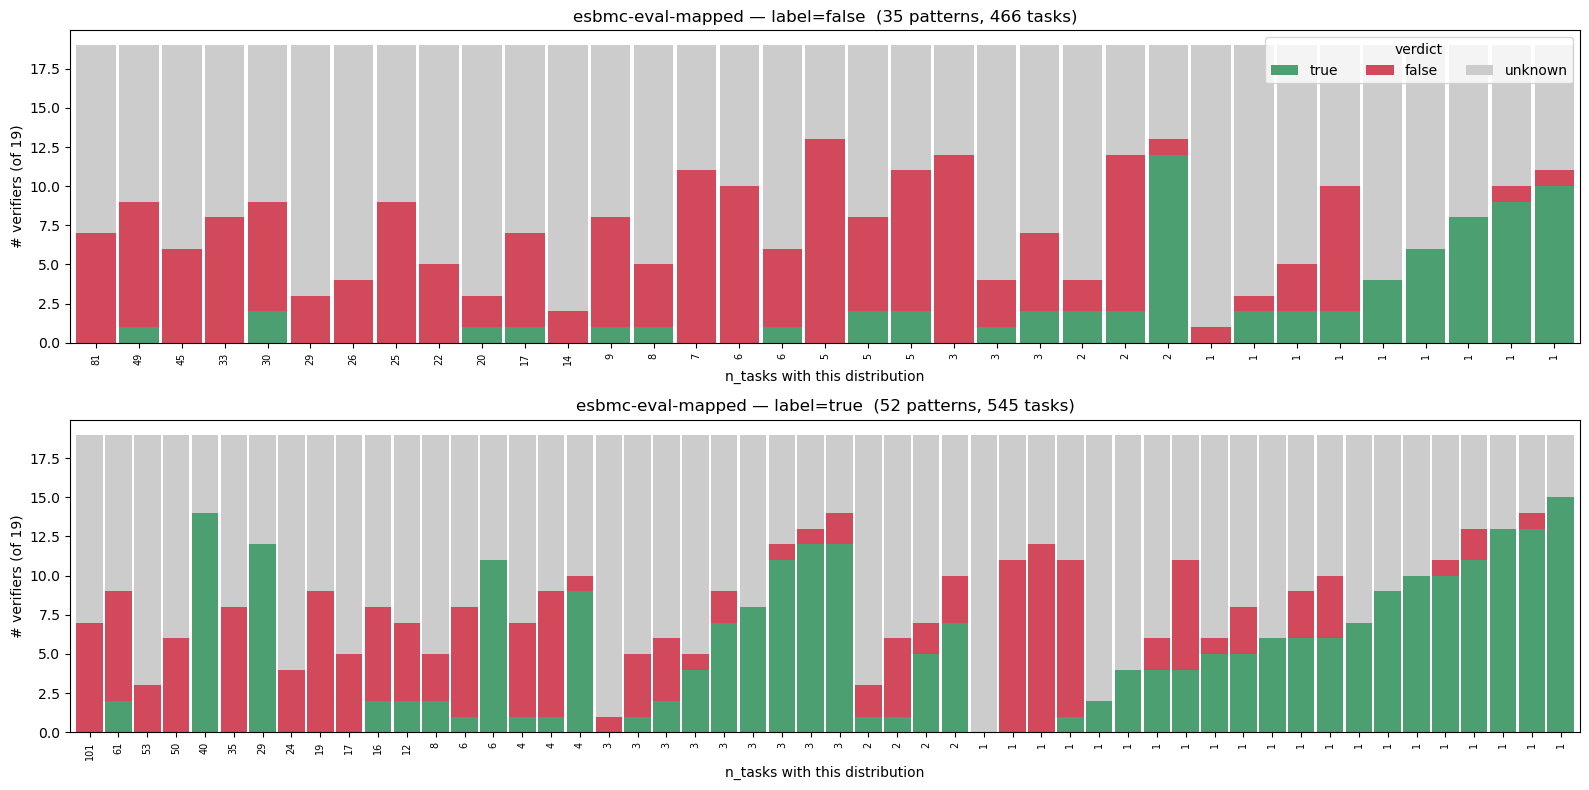

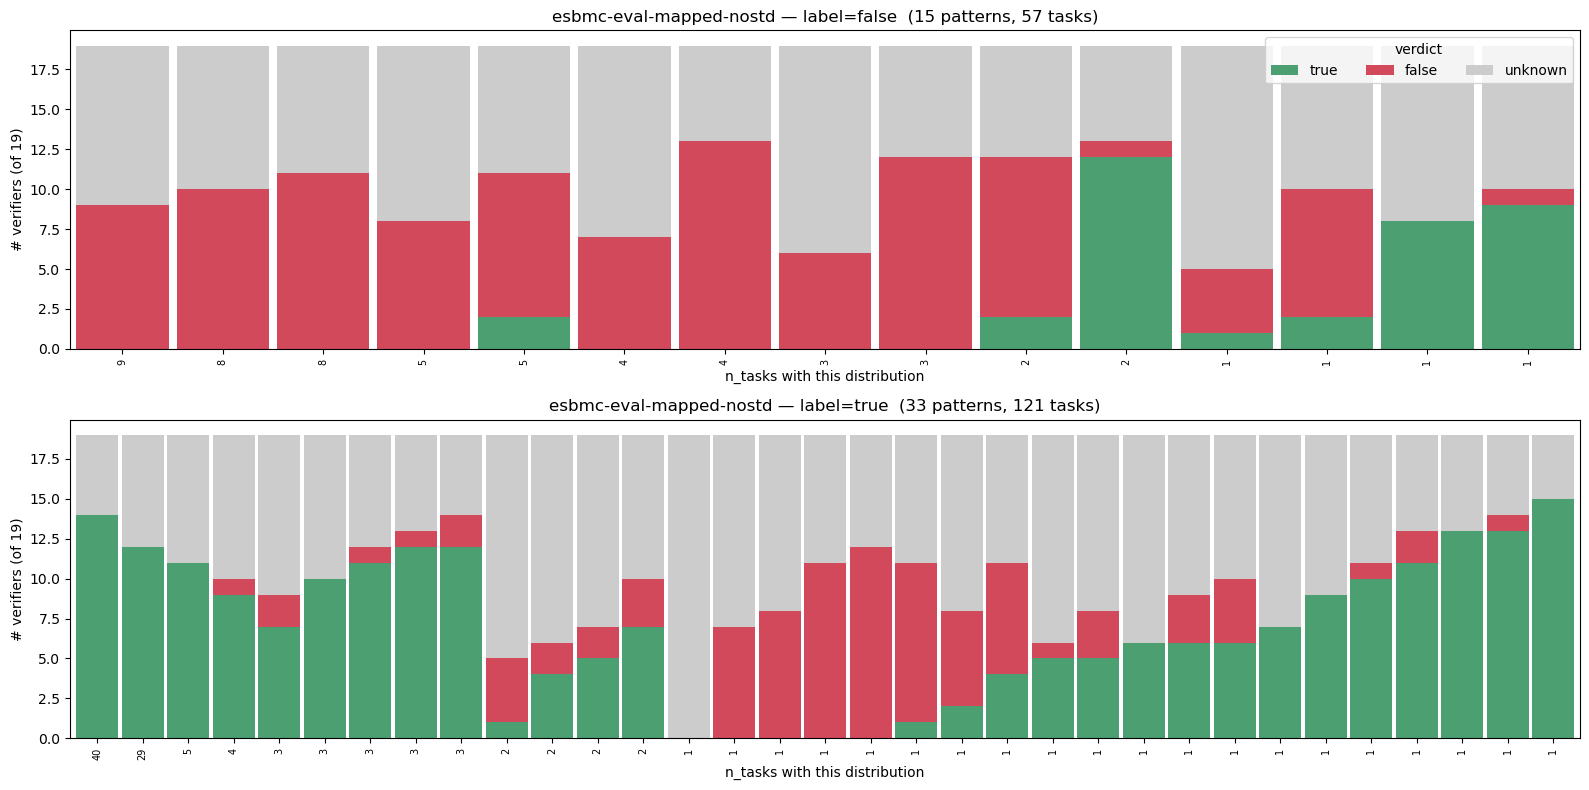

In [9]:
VCOLORS = {"true": "#4C9F70", "false": "#D1495B", "unknown": "#CCCCCC"}


def plot_patterns(cfg: str, tbl: pd.DataFrame | None = None):
    tbl = agreement[cfg] if tbl is None else tbl   # (label, true, false, unknown, n_tasks)
    n_ver = int(tbl[["true", "false", "unknown"]].sum(axis=1).max())  # verifiers per task
    labels = list(tbl.label.unique())
    fig, axes = plt.subplots(len(labels), 1, figsize=(16, 4 * len(labels)), squeeze=False)
    for ax, lab in zip(axes[:, 0], labels):
        d = (tbl[tbl.label == lab]
             .sort_values("n_tasks", ascending=False).reset_index(drop=True))
        x = range(len(d))
        bottom = np.zeros(len(d))
        for v in ("true", "false", "unknown"):
            ax.bar(x, d[v], bottom=bottom, width=0.92, color=VCOLORS[v], label=v)
            bottom += d[v].to_numpy()
        ax.set_xticks(list(x))
        ax.set_xticklabels(d.n_tasks, rotation=90, fontsize=7)
        ax.set_xlabel("n_tasks with this distribution")
        ax.set_ylabel(f"# verifiers (of {n_ver})")
        ax.set_title(f"{cfg} — label={lab}  "
                     f"({len(d)} patterns, {d.n_tasks.sum()} tasks)")
        ax.margins(x=0.004)
    axes[0, 0].legend(title="verdict", ncol=3, loc="upper right")
    fig.tight_layout()
    return fig


for cfg in MAPPED_CONFIGS:
    export_fig(plot_patterns(cfg), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on \\texttt{{{cfg}}}, "
               f"faceted by ground-truth label; bars sorted by task count.",
               label=f"fig:pattern-{cfg}")


## C++ comparison: the same views on the original suite

The same majority / unanimous tables and stacked-bar plot for the original C++ suite(s),
which only the native-C++ verifiers (`cbmc`, `divine`, `esbmc-kind`) ran — so the votes
are out of 3, not 19.



===== esbmc-eval (374 tasks, 3 verifiers) =====


majority,false,tie,true,unknown
label,,,,
false,108,0,20,36
true,6,11,191,2


unanimous,all-false,all-true,conflict,none
label,,,,
false,108,20,0,36
true,6,190,12,2


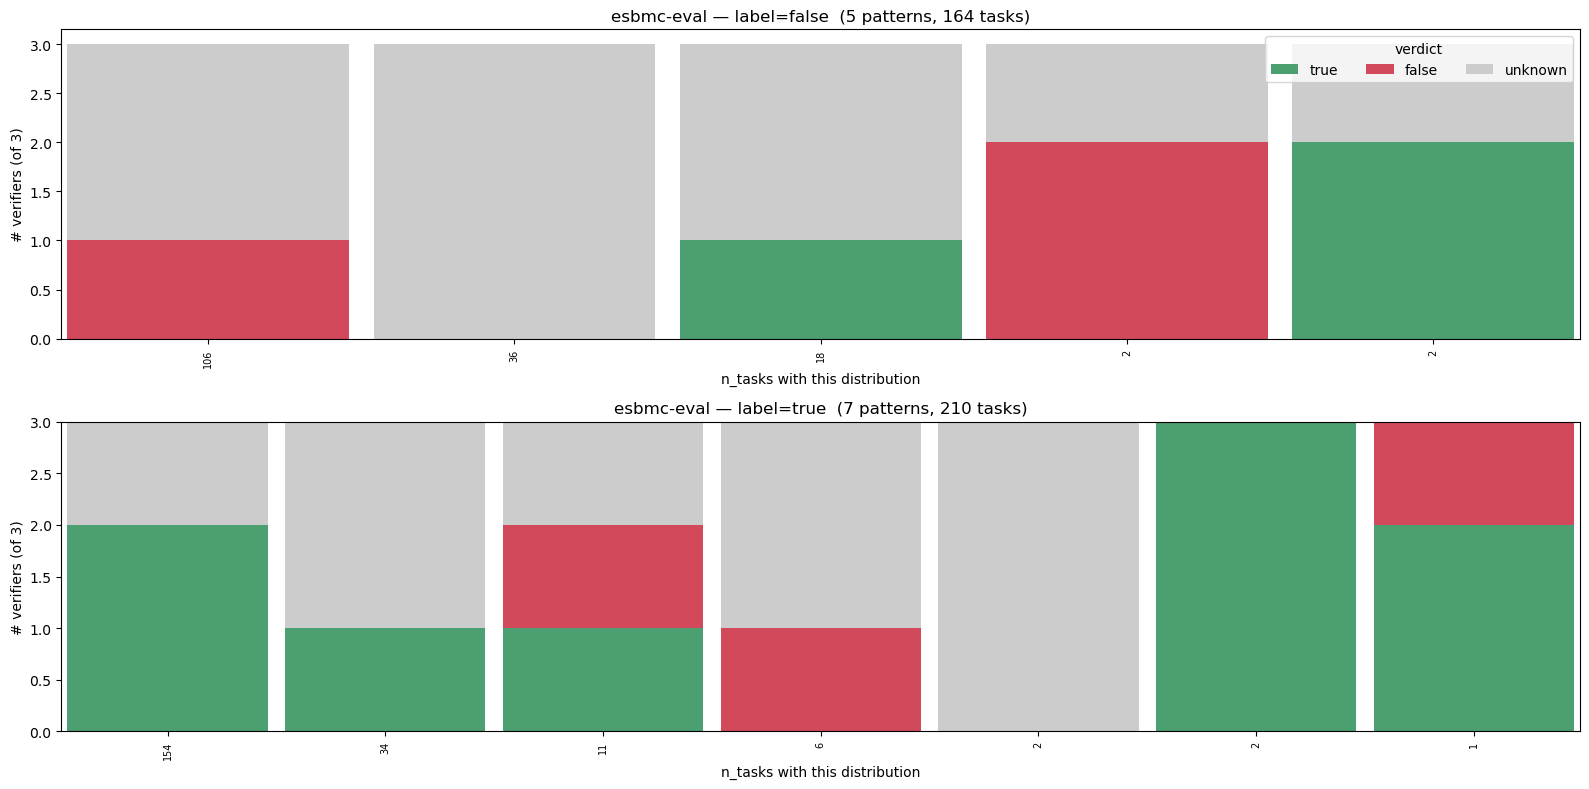

In [10]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    n_ver = df[df.config == cfg].tool.nunique()
    print(f"\n===== {cfg} ({len(pt)} tasks, {n_ver} verifiers) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on the "
                         f"original C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity vs.\\ ground-truth label on the original "
                         f"C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))
    export_fig(plot_patterns(cfg, agreement_table(cfg)), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on the original C++ suite "
               f"\\texttt{{{cfg}}}.",
               label=f"fig:pattern-{cfg}")


### C++ majority ties: who voted what

For every tie task on the original C++ suite, the per-verifier verdict (cbmc / divine /
esbmc-kind).


In [11]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    tie_tasks = pt.loc[pt.majority == "tie", "task"]
    votes = (
        df[(df.config == cfg) & (df.task.isin(tie_tasks))]
        .pivot_table(index="task", columns="tool", values="verdict", aggfunc="first")
    )
    print(f"{cfg}: {len(tie_tasks)} tie tasks")
    display(votes)


esbmc-eval: 11 tie tasks


tool,cbmc,divine,esbmc-kind
task,,,
cbmc/Templates6/cbmc_Templates6.yml,unknown,true,false
deque/deque_erase/deque_deque_erase.yml,unknown,true,false
gcc-template-tests/ctor2/gcc-template-tests_ctor2.yml,unknown,true,false
inheritance_bringup/inheritance09/inheritance_bringup_inheritance09.yml,unknown,true,false
list/list_insert/list_list_insert.yml,unknown,true,false
list/list_unique-2/list_list_unique-2.yml,unknown,true,false
list/list_unique/list_list_unique.yml,unknown,true,false
polymorphism_bringup/3_SI_virtual_ntvalDtor/polymorphism_bringup_3_SI_virtual_ntvalDtor.yml,unknown,true,false
polymorphism_bringup/dynamic_cast1/polymorphism_bringup_dynamic_cast1.yml,unknown,true,false


## Dual majority: C++ vs C (mapped)

Join each mapped suite to the original C++ suite on the shared tasks, and cross the two
majority verdicts. The diagonal is agreement between the C++ and the mapped-C consensus;
off-diagonal cells are where mapping flipped (or lost) the consensus. The heatmap shows
how those `(C++ majority, C majority)` combinations are distributed.



===== esbmc-eval (C++) vs esbmc-eval-mapped: 288 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,105,67,0,0
false,3,95,1,0
tie,3,8,0,0
unknown,0,5,0,1


c_majority          false  tie  true  unknown
label cpp_majority                           
false false            92    1     2        0
      true              9    0     2        0
      unknown           5    0     0        0
true  false             3    0     1        0
      tie               8    0     3        0
      true             58    0   103        0
      unknown           0    0     0        1

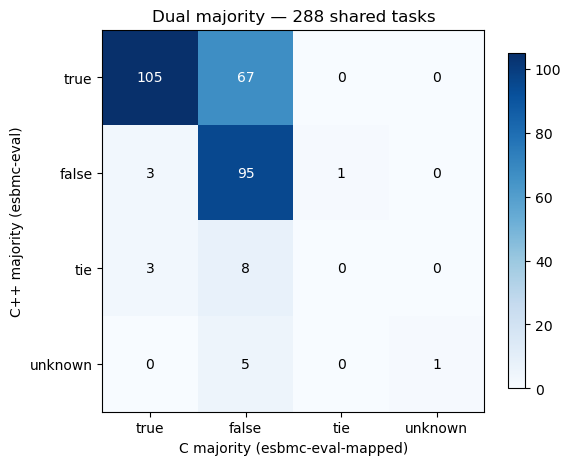


===== esbmc-eval (C++) vs esbmc-eval-mapped-nostd: 178 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,109,6,0,0
false,3,52,0,0
tie,3,3,0,0
unknown,0,1,0,1


c_majority          false  true  unknown
label cpp_majority                      
false false            51     2        0
      true              1     2        0
      unknown           1     0        0
true  false             1     1        0
      tie               3     3        0
      true              5   107        0
      unknown           0     0        1

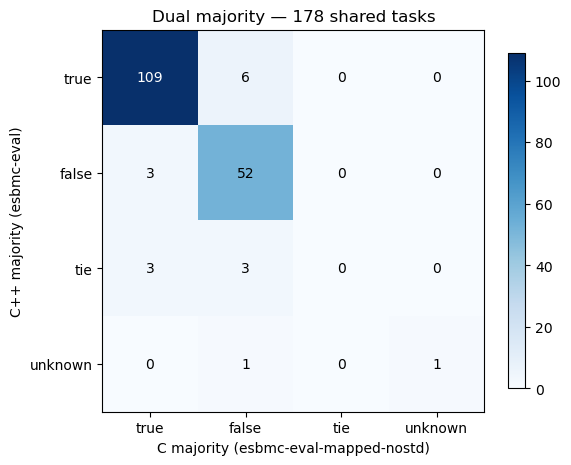

In [12]:
MAJ_ORDER = ["true", "false", "tie", "unknown"]
CPP_REF = ORIGINAL_CONFIGS[0]  # original C++ suite used as the reference


def dual_majority(c_cfg: str, cpp_cfg: str = CPP_REF) -> pd.DataFrame:
    """Per-task C++ vs mapped-C majority, joined on the shared tasks (and label)."""
    def m(cfg, col):
        return (collapse(per_task_counts(cfg))[["task", "label", "majority"]]
                .rename(columns={"majority": col}))
    return m(cpp_cfg, "cpp_majority").merge(m(c_cfg, "c_majority"), on=["task", "label"])


def dual_crosstab(dm: pd.DataFrame) -> pd.DataFrame:
    return (pd.crosstab(dm.cpp_majority, dm.c_majority)
            .reindex(index=MAJ_ORDER, columns=MAJ_ORDER, fill_value=0))


def plot_dual(ct: pd.DataFrame, c_cfg: str, n: int):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(ct.values, cmap="Blues")
    ax.set_xticks(range(len(MAJ_ORDER)), MAJ_ORDER)
    ax.set_yticks(range(len(MAJ_ORDER)), MAJ_ORDER)
    ax.set_xlabel(f"C majority ({c_cfg})")
    ax.set_ylabel(f"C++ majority ({CPP_REF})")
    ax.set_title(f"Dual majority — {n} shared tasks")
    hi = ct.values.max()
    for i in range(len(MAJ_ORDER)):
        for j in range(len(MAJ_ORDER)):
            v = ct.values[i, j]
            ax.text(j, i, int(v), ha="center", va="center",
                    color="white" if v > hi / 2 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    return fig


for c_cfg in MAPPED_CONFIGS:
    dm = dual_majority(c_cfg)
    ct = dual_crosstab(dm)
    print(f"\n===== {CPP_REF} (C++) vs {c_cfg}: {len(dm)} shared tasks =====")
    display(export_table(ct, "rq2", f"dual_majority_{c_cfg}",
                         f"Majority verdict on the original C++ suite (rows) vs.\\ on "
                         f"\\texttt{{{c_cfg}}} (columns), over the {len(dm)} shared tasks.",
                         label=f"tab:dual-majority-{c_cfg}"))
    display(pd.crosstab([dm.label, dm.cpp_majority], dm.c_majority))  # label-split, inline only
    export_fig(plot_dual(ct, c_cfg, len(dm)), "rq2", f"dual_majority_{c_cfg}_heatmap",
               f"Distribution of (C++, \\texttt{{{c_cfg}}}) majority-verdict combinations "
               f"over the {len(dm)} shared tasks.",
               label=f"fig:dual-majority-{c_cfg}", width=r"0.6\linewidth")


# RQ3 — Performance: CPU time & memory

Resource usage per task suite, treated separately for now (no cross-suite pairing yet).
CPU time is in seconds (timeouts land at ~900 s); memory is in GB. Note these are *all*
runs across the retained verifiers, so the distributions mix fast error-exits, real
solves, and timeouts — split by outcome later if needed.


In [13]:
res = df.assign(
    mem_gb=df.memory / 1e9,
    timeout=df.status.str.contains("TIMEOUT", na=False),
)

# Per-suite resource summary.
perf = (
    res.groupby("config", observed=True)
    .agg(
        runs=("cputime", "size"),
        timeouts=("timeout", "sum"),
        cpu_median_s=("cputime", "median"),
        cpu_p90_s=("cputime", lambda s: s.quantile(0.9)),
        cpu_max_s=("cputime", "max"),
        cpu_total_h=("cputime", lambda s: s.sum() / 3600),
        mem_median_gb=("mem_gb", "median"),
        mem_p90_gb=("mem_gb", lambda s: s.quantile(0.9)),
        mem_max_gb=("mem_gb", "max"),
    )
    .round(3)
)
display(export_table(perf, "rq3", "perf_summary",
                     "CPU time and memory per task suite (all retained verifiers, all "
                     "runs). Times in seconds, memory in GB.",
                     label="tab:perf-summary"))

# Per-verifier medians within each suite.
cpu_by_tool = res.pivot_table(index="tool", columns="config", values="cputime",
                              aggfunc="median", observed=False).round(2)
mem_by_tool = res.pivot_table(index="tool", columns="config", values="mem_gb",
                              aggfunc="median", observed=False).round(3)
print("Median CPU time (s) per verifier × suite:")
display(export_table(cpu_by_tool, "rq3", "cpu_median_by_tool",
                     "Median CPU time (s) per verifier and task suite.",
                     label="tab:cpu-median-by-tool"))
print("Median memory (GB) per verifier × suite:")
display(export_table(mem_by_tool, "rq3", "mem_median_by_tool",
                     "Median memory (GB) per verifier and task suite.",
                     label="tab:mem-median-by-tool"))


,runs,timeouts,cpu_median_s,cpu_p90_s,cpu_max_s,cpu_total_h,mem_median_gb,mem_p90_gb,mem_max_gb
config,,,,,,,,,
esbmc-eval,1122,9,0.382,18.492,900.900,4.397,0.048,0.369,15.0
esbmc-eval-mapped,19209,1135,7.395,290.837,903.145,449.507,0.151,1.095,15.0
esbmc-eval-mapped-nostd,3382,115,2.421,57.980,902.627,49.081,0.118,0.604,15.0


Median CPU time (s) per verifier × suite:


config,esbmc-eval,esbmc-eval-mapped,esbmc-eval-mapped-nostd
tool,,,
2ls,NaN,0.12,0.12
bubaak,NaN,1.32,0.29
bubaak-split,NaN,2.09,1.00
cbmc,0.14,0.11,0.11
cpachecker,NaN,7.27,6.70
divine,4.43,16.99,3.19
emergentheta,NaN,12.03,3.16
esbmc-kind,0.40,0.39,0.38
mopsa,NaN,18.47,1.86


Median memory (GB) per verifier × suite:


config,esbmc-eval,esbmc-eval-mapped,esbmc-eval-mapped-nostd
tool,,,
2ls,NaN,0.005,0.005
bubaak,NaN,0.041,0.038
bubaak-split,NaN,0.061,0.058
cbmc,0.006,0.006,0.006
cpachecker,NaN,0.179,0.167
divine,0.204,0.568,0.170
emergentheta,NaN,0.463,0.126
esbmc-kind,0.048,0.048,0.047
mopsa,NaN,0.107,0.081


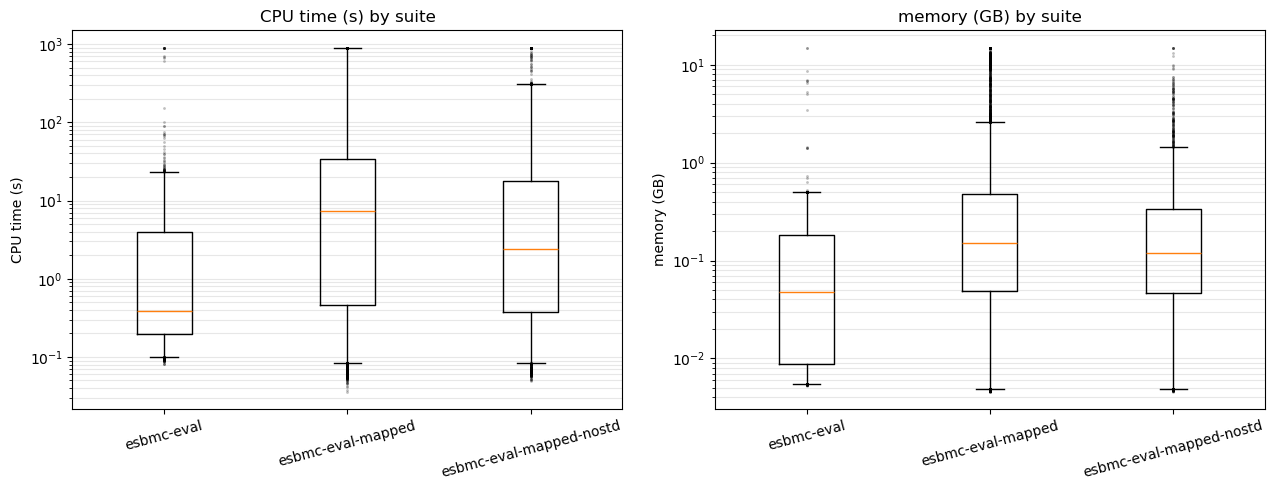

In [14]:
# Distributions per suite (log scale; whiskers at 5th/95th pct, dots are runs beyond).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, lab) in zip(axes, [("cputime", "CPU time (s)"), ("mem_gb", "memory (GB)")]):
    data = [res.loc[res.config == c, col].dropna().to_numpy() for c in CONFIGS]
    ax.boxplot(data, tick_labels=CONFIGS, whis=(5, 95),
               flierprops=dict(marker=".", markersize=2, alpha=0.25))
    ax.set_yscale("log")
    ax.set_ylabel(lab)
    ax.set_title(f"{lab} by suite")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", which="both", alpha=0.3)
fig.tight_layout()
export_fig(fig, "rq3", "resource_boxplots",
           "CPU time and memory distributions per task suite (log scale; whiskers at the "
           "5th/95th percentile).",
           label="fig:resource-box")


## Quantile (cactus) plots

BenchExec-style: per verifier, take its **correctly solved** tasks (`bx_category ==
"correct"`), sort their CPU times ascending, and plot `x = # solved`, `y = CPU time`
(log). A curve further right solves more tasks; lower means faster. One plot per suite
below, then one over the C/C++ **shared** tasks where the native-C++ verifiers appear
twice — once on the C++ input (dashed), once on the mapped-C input (solid, same colour).


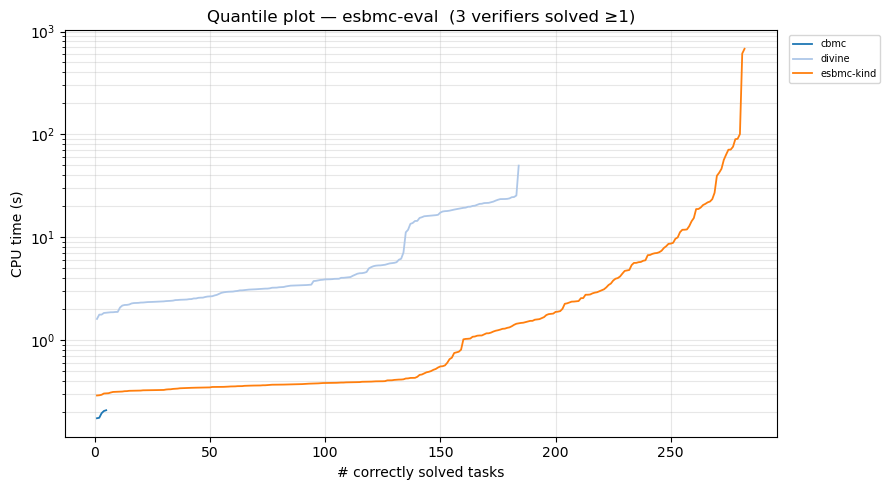

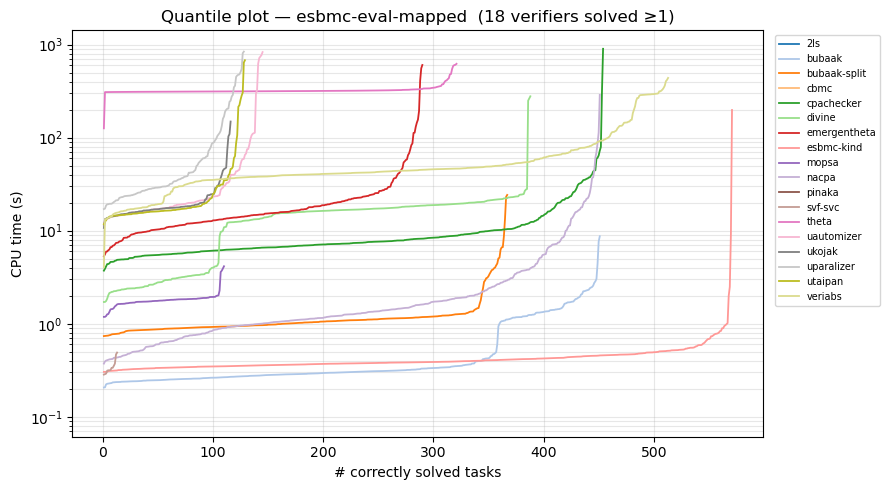

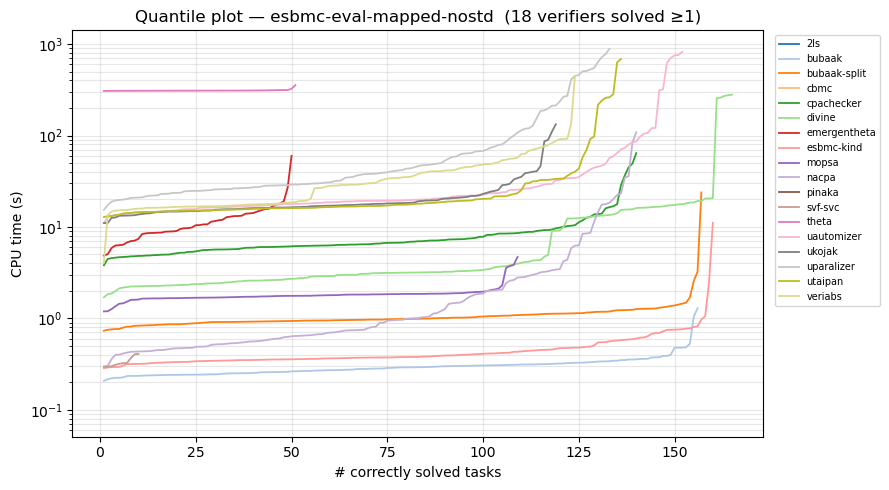

In [15]:
def solved_times(d: pd.DataFrame) -> np.ndarray:
    """Sorted CPU times of correctly-solved runs (BenchExec 'correct')."""
    return d.loc[d.bx_category == "correct", "cputime"].dropna().sort_values().to_numpy()


def quantile_plot(series: dict, ax, title: str):
    """series: label -> sorted cpu-time array. Native-C++ curves ('… (C++)') are dashed
    and share the colour of their mapped-C namesake."""
    bases = list(dict.fromkeys(lbl.replace(" (C++)", "") for lbl in series))
    cmap = plt.get_cmap("tab20")
    color = {b: cmap(i % 20) for i, b in enumerate(bases)}
    for lbl, arr in series.items():
        if len(arr) == 0:
            continue
        ax.plot(range(1, len(arr) + 1), arr, label=lbl,
                color=color[lbl.replace(" (C++)", "")], lw=1.3,
                ls="--" if lbl.endswith("(C++)") else "-")
    ax.set_yscale("log")
    ax.set_xlabel("# correctly solved tasks")
    ax.set_ylabel("CPU time (s)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1.0))


for cfg in CONFIGS:
    sub = df[df.config == cfg]
    series = {t: solved_times(sub[sub.tool == t]) for t in sorted(sub.tool.unique())}
    series = {k: v for k, v in series.items() if len(v)}
    fig, ax = plt.subplots(figsize=(9, 5))
    quantile_plot(series, ax, f"Quantile plot — {cfg}  ({len(series)} verifiers solved ≥1)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_{cfg}",
               f"Quantile (cactus) plot of CPU time for correctly solved tasks on "
               f"\\texttt{{{cfg}}}; one curve per verifier.",
               label=f"fig:quantile-{cfg}")


### Shared C/C++ tasks — all verifiers, native-C++ ones doubled

One plot per mapped suite, restricted to tasks present in **both** that suite and the
C++ original. Every mapped-C verifier contributes one (solid) curve; the native-C++
verifiers (cbmc, divine, esbmc-kind) contribute a second, dashed curve from their C++
run, so the mapping cost is visible as the gap between a tool's solid and dashed lines.


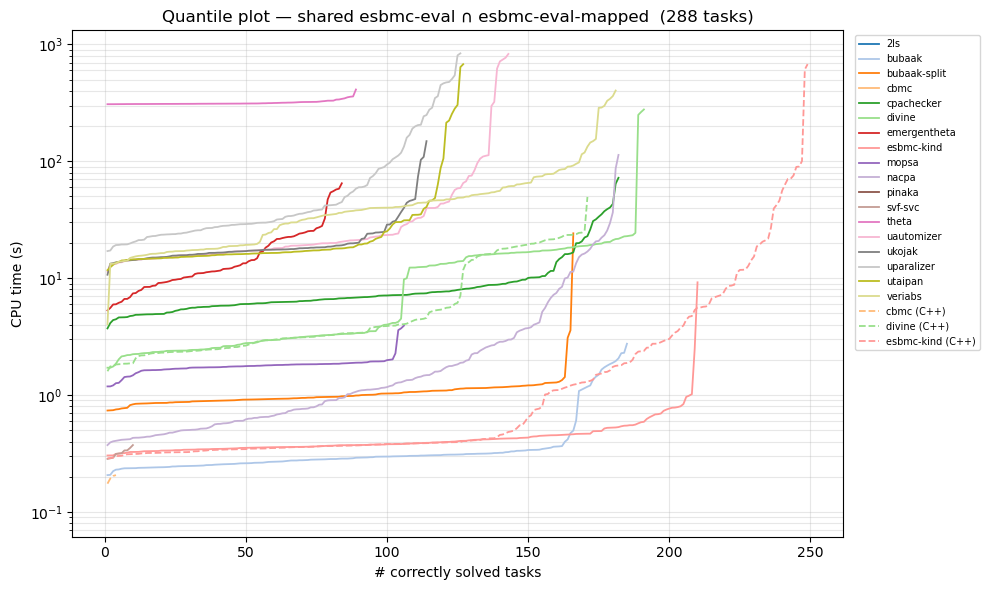

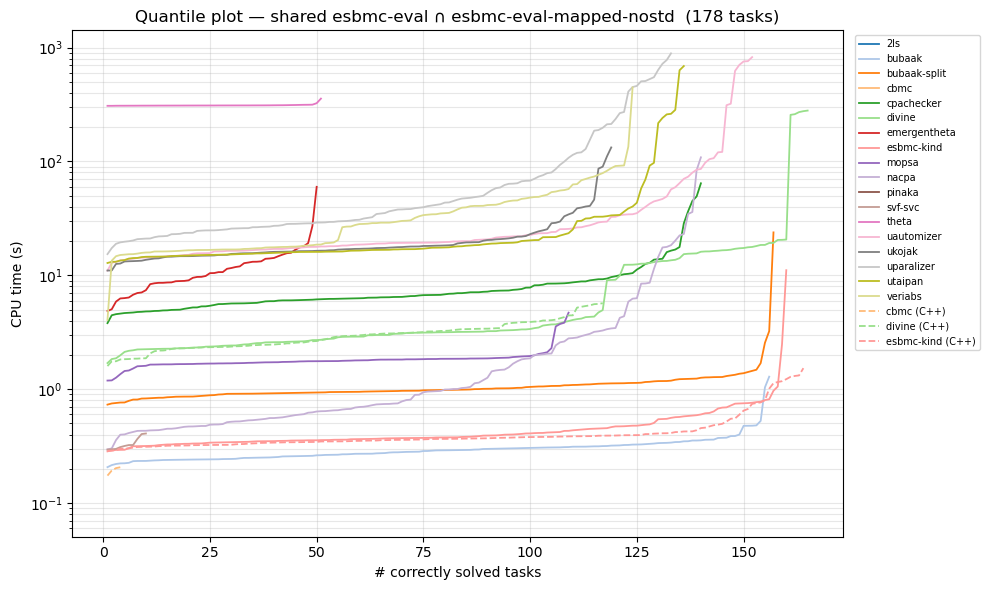

In [16]:
def shared_quantile(c_cfg: str, cpp_cfg: str = CPP_REF):
    """Cactus plot over the tasks shared by cpp_cfg and c_cfg; native-C++ tools doubled."""
    shared = set(df.loc[df.config == cpp_cfg, "task"]) & set(df.loc[df.config == c_cfg, "task"])
    series = {}
    csub = df[(df.config == c_cfg) & (df.task.isin(shared))]
    for t in sorted(csub.tool.unique()):
        series[t] = solved_times(csub[csub.tool == t])             # mapped-C run (solid)
    psub = df[(df.config == cpp_cfg) & (df.task.isin(shared))]
    for t in sorted(psub.tool.unique()):
        series[f"{t} (C++)"] = solved_times(psub[psub.tool == t])  # C++ run (dashed)
    series = {k: v for k, v in series.items() if len(v)}

    fig, ax = plt.subplots(figsize=(10, 6))
    quantile_plot(series, ax, f"Quantile plot — shared {cpp_cfg} ∩ {c_cfg}  ({len(shared)} tasks)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_shared_{c_cfg}",
               f"Quantile (cactus) plot over the {len(shared)} tasks shared by the C++ "
               f"suite \\texttt{{{cpp_cfg}}} and \\texttt{{{c_cfg}}}. Native-C++ verifiers "
               f"appear twice: dashed = C++ input, solid = mapped-C input (same colour).",
               label=f"fig:quantile-shared-{c_cfg}")


# One shared-task cactus per mapped suite (rename-proof: no suite name hardcoded).
for c_cfg in MAPPED_CONFIGS:
    shared_quantile(c_cfg)
